In [20]:
using JLD2
using PyPlot
using Statistics

In [21]:
# Load stripes data
@load "../../../Image_analysis/V2/Saved_exp_data/Stripes_2026_02_11_0001.jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds

# size_pxl = 0.187e-6
size_pxl = 0.1966e-6 # New pxl size since 2025/12/31

# Convert pxl to m
centers_stripes_ds, major_axis_stripes_ds, minor_axis_stripes_ds = centers_stripes_ds*size_pxl, major_axis_stripes_ds*size_pxl, minor_axis_stripes_ds*size_pxl

N_stripe = 4e4;

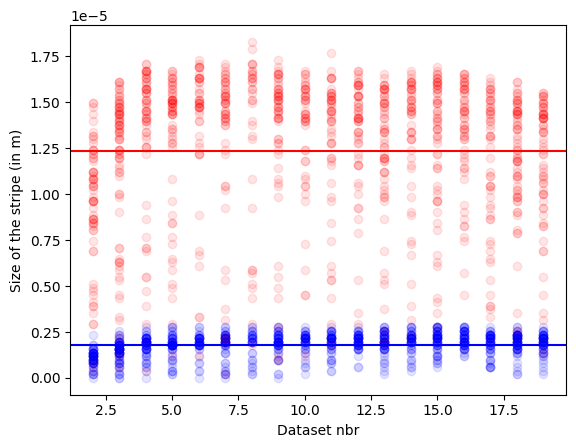

In [22]:
close("all")
fig, ax = subplots()

for i = 1:size(nbr_stripes_ds)[1]
    for j = 1:size(nbr_stripes_ds)[2]
        for k = 1:length(major_axis_stripes_ds[i][j])
            ax.scatter(i, major_axis_stripes_ds[i][j][k], color="r", alpha=0.1, label="Major axis")
            ax.scatter(i, minor_axis_stripes_ds[i][j][k], color="b", alpha=0.1, label="Minor axis")
        end
    end
end

mean_major_axis = mean(vcat(Iterators.flatten(Iterators.flatten(major_axis_stripes_ds))...))
mean_minor_axis = mean(vcat(Iterators.flatten(Iterators.flatten(minor_axis_stripes_ds))...))

axhline(mean_major_axis, color="r")#, nbr_stripes_ds[1], nbr_stripes_ds[end])
axhline(mean_minor_axis, color="b")

ax.set_xlabel("Dataset nbr")
ax.set_ylabel("Size of the stripe (in m)")
pygui(false);

### Reconstruct a stripe

In [23]:
function sim_stripe(x, y, M, m, N)
    """ Elliptical gaussian with major axis M, minor axis m, and N particles """
    return N/(π*M*m) * exp.(-(x/M).^2).*exp.(-(y/m).^2)
end

sim_stripe (generic function with 1 method)

In [40]:
X = [-200:200;]*size_pxl
Y = [-100:100;]*size_pxl

X_img = X' .* ones(length(Y))
Y_img = ones(length(X))' .* Y

Stripe_img = sim_stripe(X_img, Y_img, mean_major_axis, mean_minor_axis, N_stripe)

close("all")
fig = subplot()
imshow(Stripe_img, extent=[X[1], X[end], Y[1], Y[end]])
xlabel("X")
ylabel("Y")
pygui(true); show()
# pygui(false);

In [30]:
density_distribution = zeros(length(X_img))

for i = 1:length(Y)
    for j = 1:length(X)
        density_distribution[(i-1)*length(X)+j] = Stripe_img[i, j]
    end
end

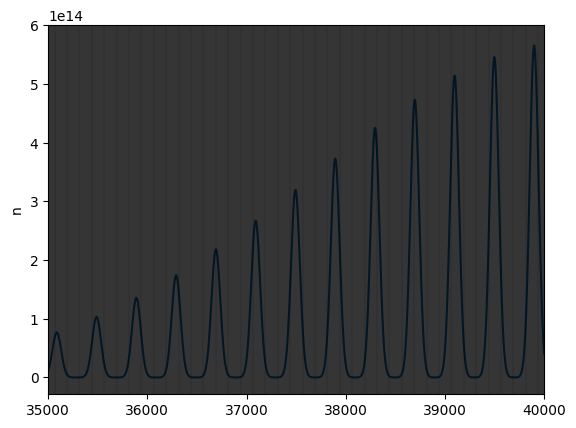

In [38]:
plot(density_distribution)

densities_cuts = []

counter = 0
for i = 1:length(density_distribution)
    counter += density_distribution[i]
    if counter > 30
        axvline(i, linewidth=0.1, color="black")
        counter = 0
        push!(densities_cuts, density_distribution[i])
    end
end

xlim(35000, 40000)

ylabel("n")

# pygui(true); show()
pygui(false);

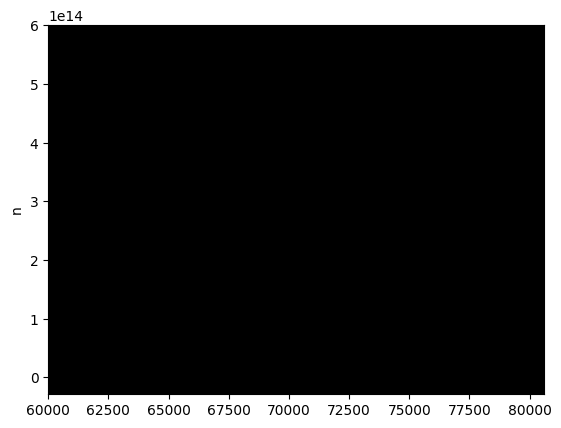

In [32]:
sort_density_distribution = sort(density_distribution)

plot(sort_density_distribution)

densities_cuts = []

counter = 0
for i = 1:length(sort_density_distribution)
    counter += sort_density_distribution[i]
    if counter > 30
        axvline(i, linewidth=0.1, color="black")
        counter = 0
        push!(densities_cuts, sort_density_distribution[i])
    end
end

xlim(60000, length(sort_density_distribution))

ylabel("n")

# pygui(true); show()
pygui(false);

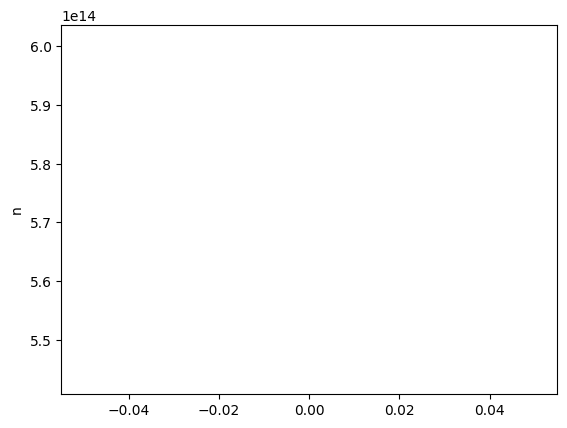

PyObject Text(24.000000000000007, 0.5, 'n')

In [28]:
plot(densities_cuts)
# plot(round.(Int, densities_cuts))
ylabel("n")